# Conformal Prediction and Ensembling

Use this notebook to build uncertainty-aware prediction sets and ensemble-based screening strategies. It loads the saved random forest and gradient boosting models, then computes split conformal prediction with a global calibration rule and a locally adaptive rule. It also exports a test-set report with the molecule, isomer, medium, experimental conditions, fitted value, and interval bounds sorted by fitted value.


In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

sns.set_theme(style="whitegrid", context="talk")

DATA_SPLITS_ROOT = Path("../data/splits/Nd_3plus")
MODEL_RESULTS_ROOT = Path("../results/model_fitting/Nd_3plus")
CONFORMAL_RESULTS_ROOT = Path("../results/conformal_prediction/Nd_3plus")
CONFORMAL_RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

TARGET_COL = "Log K1"
METAL_COL = "Metal"
MOLECULE_COL = "Molecule"
ISOMER_COL = "Isomer"
RANDOM_SEED = 42
ALPHA = 0.10
GLOBAL_CALIBRATION_SPLITS = ["calibration_global", "calibration_local"]
LOCAL_CALIBRATION_SPLIT = "calibration_local"
TEST_SPLIT = "test"
BASE_MODELS = ["random_forest", "gradient_boosting"]
REPORT_COLUMNS = [
    MOLECULE_COL,
    ISOMER_COL,
    METAL_COL,
    "Medium",
    "Temperature (K)",
    "Concentration (M)",
]

CONFORMAL_CONFIG = {
    "alpha": ALPHA,
    "global_calibration_splits": GLOBAL_CALIBRATION_SPLITS,
    "local_calibration_split": LOCAL_CALIBRATION_SPLIT,
    "test_split": TEST_SPLIT,
    "base_models": BASE_MODELS,
    "local_scale_model": {
        "name": "RandomForestRegressor",
        "parameters": {
            "n_estimators": 200,
            "random_state": RANDOM_SEED,
            "n_jobs": -1,
            "min_samples_leaf": 5,
        },
    },
}


def load_split(split_name: str) -> pd.DataFrame:
    split_path = DATA_SPLITS_ROOT / f"{split_name}.csv"
    frame = pd.read_csv(split_path)
    frame.columns = [column.strip() for column in frame.columns]
    frame[METAL_COL] = frame[METAL_COL].astype(str).str.strip()
    frame[MOLECULE_COL] = frame[MOLECULE_COL].astype(str).str.strip()
    frame[ISOMER_COL] = frame[ISOMER_COL].astype(str).str.strip()
    frame[TARGET_COL] = pd.to_numeric(frame[TARGET_COL], errors="coerce")
    return frame


def load_run_config() -> dict:
    return json.loads((MODEL_RESULTS_ROOT / "run_config.json").read_text())


def load_model_artifacts() -> pd.DataFrame:
    return pd.read_csv(MODEL_RESULTS_ROOT / "model_artifacts.csv")


def load_selected_features() -> list[str]:
    selected = pd.read_csv(MODEL_RESULTS_ROOT / "selected_features.csv")
    return selected["feature"].tolist()


def conformal_quantile(scores: np.ndarray, alpha: float) -> float:
    scores = np.asarray(scores, dtype=float)
    scores = scores[np.isfinite(scores)]
    if scores.size == 0:
        raise ValueError("Cannot compute a conformal quantile from an empty score array.")
    rank = int(np.ceil((scores.size + 1) * (1 - alpha)))
    rank = min(max(rank, 1), scores.size)
    return float(np.sort(scores)[rank - 1])


def make_scale_model() -> RandomForestRegressor:
    return RandomForestRegressor(**CONFORMAL_CONFIG["local_scale_model"]["parameters"])


def get_saved_pipeline(model_name: str):
    model_path = MODEL_RESULTS_ROOT / "models" / f"{model_name}.joblib"
    return joblib.load(model_path)


def build_conformal_outputs(model_name: str, feature_columns: list[str], split_frames: dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    base_pipeline = get_saved_pipeline(model_name)
    display_name = load_model_artifacts().loc[lambda df: df["model"] == model_name, "display_name"].iloc[0]

    calibration_frames = [split_frames[name] for name in GLOBAL_CALIBRATION_SPLITS]
    global_calibration_frame = pd.concat(calibration_frames, ignore_index=True)
    local_calibration_frame = split_frames[LOCAL_CALIBRATION_SPLIT].copy()
    test_frame = split_frames[TEST_SPLIT].copy().reset_index(drop=True)

    global_calibration_predictions = np.asarray(base_pipeline.predict(global_calibration_frame[feature_columns]), dtype=float)
    global_calibration_scores = np.abs(global_calibration_frame[TARGET_COL].to_numpy(dtype=float) - global_calibration_predictions)
    global_qhat = conformal_quantile(global_calibration_scores, ALPHA)

    local_base_predictions = np.asarray(base_pipeline.predict(local_calibration_frame[feature_columns]), dtype=float)
    local_residuals = np.abs(local_calibration_frame[TARGET_COL].to_numpy(dtype=float) - local_base_predictions)

    scale_model = make_scale_model()
    scale_model.fit(local_calibration_frame[feature_columns], local_residuals)
    local_scale_calibration = np.asarray(scale_model.predict(local_calibration_frame[feature_columns]), dtype=float)
    local_scale_calibration = np.clip(local_scale_calibration, a_min=1e-8, a_max=None)
    local_scores = local_residuals / local_scale_calibration
    local_qhat = conformal_quantile(local_scores, ALPHA)

    test_predictions = np.asarray(base_pipeline.predict(test_frame[feature_columns]), dtype=float)
    test_actual = test_frame[TARGET_COL].to_numpy(dtype=float)
    global_lower = test_predictions - global_qhat
    global_upper = test_predictions + global_qhat

    local_scale_test = np.asarray(scale_model.predict(test_frame[feature_columns]), dtype=float)
    local_scale_test = np.clip(local_scale_test, a_min=1e-8, a_max=None)
    local_lower = test_predictions - local_qhat * local_scale_test
    local_upper = test_predictions + local_qhat * local_scale_test

    base_columns = REPORT_COLUMNS.copy()
    report_metadata = test_frame[base_columns].copy()

    global_results = pd.DataFrame(
        {
            "model": model_name,
            "display_name": display_name,
            "method": "global",
            "split": TEST_SPLIT,
            "observed": test_actual,
            "predicted": test_predictions,
            "lower": global_lower,
            "upper": global_upper,
            "interval_width": global_upper - global_lower,
            "residual": test_actual - test_predictions,
            "calibration_qhat": global_qhat,
            "calibration_size": len(global_calibration_frame),
        }
    )

    local_results = pd.DataFrame(
        {
            "model": model_name,
            "display_name": display_name,
            "method": "local",
            "split": TEST_SPLIT,
            "observed": test_actual,
            "predicted": test_predictions,
            "lower": local_lower,
            "upper": local_upper,
            "interval_width": local_upper - local_lower,
            "residual": test_actual - test_predictions,
            "calibration_qhat": local_qhat,
            "calibration_size": len(local_calibration_frame),
            "local_scale": local_scale_test,
        }
    )

    for result_frame in [global_results, local_results]:
        for column in base_columns:
            result_frame[column] = report_metadata[column].values

    calibration_scores = pd.concat(
        [
            pd.DataFrame(
                {
                    "model": model_name,
                    "display_name": display_name,
                    "calibration_source": "global_combined",
                    "score": global_calibration_scores,
                }
            ),
            pd.DataFrame(
                {
                    "model": model_name,
                    "display_name": display_name,
                    "calibration_source": "local_held_out",
                    "score": local_scores,
                }
            ),
        ],
        ignore_index=True,
    )

    return global_results, local_results, calibration_scores


def save_json(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, indent=2, sort_keys=True))


In [2]:
run_config = load_run_config()
feature_columns = run_config["feature_columns"]
model_artifacts = load_model_artifacts()
selected_model_artifacts = model_artifacts.loc[model_artifacts["model"].isin(BASE_MODELS)].copy()

split_frames = {
    split_name: load_split(split_name)
    for split_name in ["calibration_global", "calibration_local", "test"]
}

all_results = []
score_frames = []
for model_name in BASE_MODELS:
    global_results, local_results, calibration_scores = build_conformal_outputs(
        model_name=model_name,
        feature_columns=feature_columns,
        split_frames=split_frames,
    )
    all_results.extend([global_results, local_results])
    score_frames.append(calibration_scores)

conformal_results_df = pd.concat(all_results, ignore_index=True)
calibration_scores_df = pd.concat(score_frames, ignore_index=True)

conformal_results_df.to_csv(CONFORMAL_RESULTS_ROOT / "test_prediction_intervals.csv", index=False)
calibration_scores_df.to_csv(CONFORMAL_RESULTS_ROOT / "calibration_scores.csv", index=False)
save_json(CONFORMAL_RESULTS_ROOT / "run_config.json", {**CONFORMAL_CONFIG, "feature_columns": feature_columns, "base_models": BASE_MODELS})
selected_model_artifacts.to_csv(CONFORMAL_RESULTS_ROOT / "selected_model_artifacts.csv", index=False)

test_report_df = conformal_results_df[
    [
        "model",
        "display_name",
        "method",
        "predicted",
        "observed",
        "lower",
        "upper",
        "interval_width",
        MOLECULE_COL,
        ISOMER_COL,
        METAL_COL,
        "Medium",
        "Temperature (K)",
        "Concentration (M)",
    ]
].copy()
test_report_df = test_report_df.sort_values("predicted", ascending=False).reset_index(drop=True)
test_report_df.to_csv(CONFORMAL_RESULTS_ROOT / "test_interval_report.csv", index=False)

summary_df = conformal_results_df.groupby(["model", "method"]).agg(
    mean_interval_width=("interval_width", "mean"),
    median_interval_width=("interval_width", "median"),
    test_mse=("residual", lambda x: float(np.mean(np.asarray(x) ** 2))),
).reset_index()

print(summary_df.to_string(index=False))
print(f"Saved report to {CONFORMAL_RESULTS_ROOT / 'test_interval_report.csv'}")


            model method  mean_interval_width  median_interval_width  test_mse
gradient_boosting global             8.274852               8.274852  3.978800
gradient_boosting  local             6.472375               7.336297  3.978800
    random_forest global             7.868533               7.868533  3.089983
    random_forest  local             6.680846               5.266991  3.089983
Saved report to ../results/conformal_prediction/Nd_3plus/test_interval_report.csv


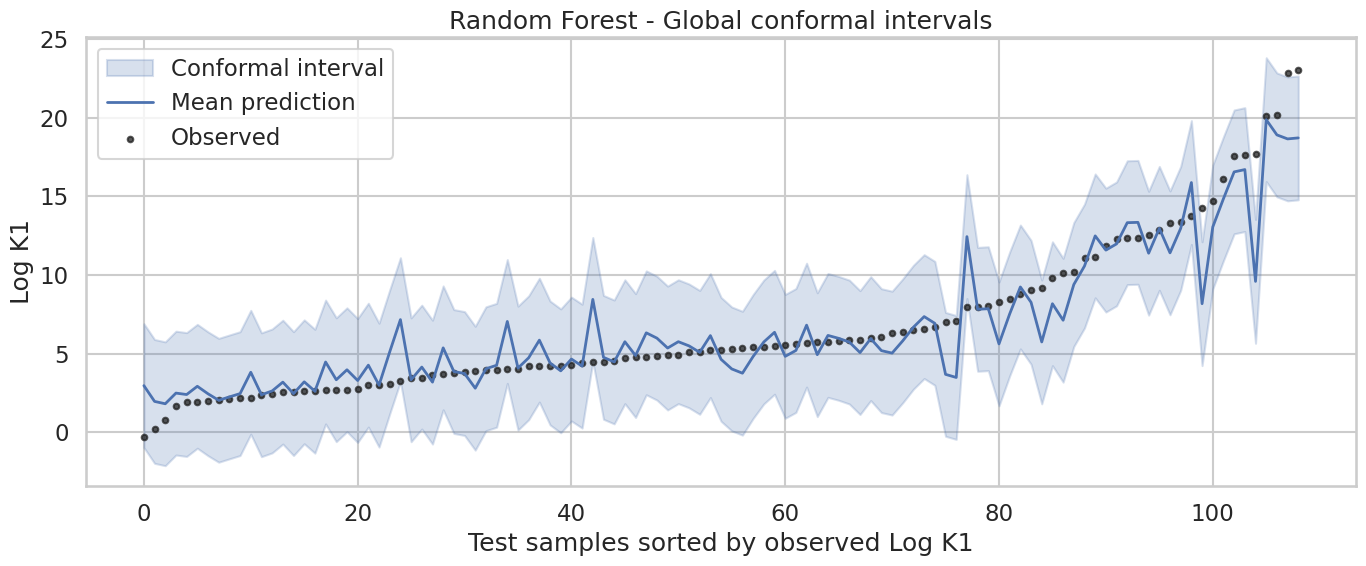

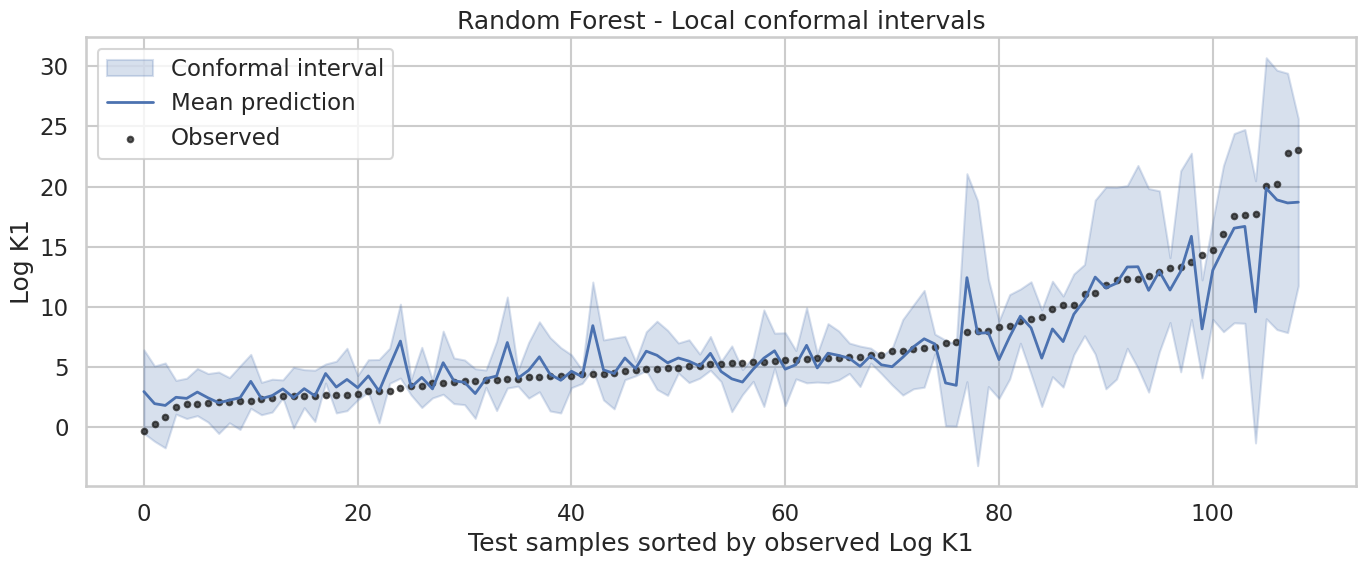

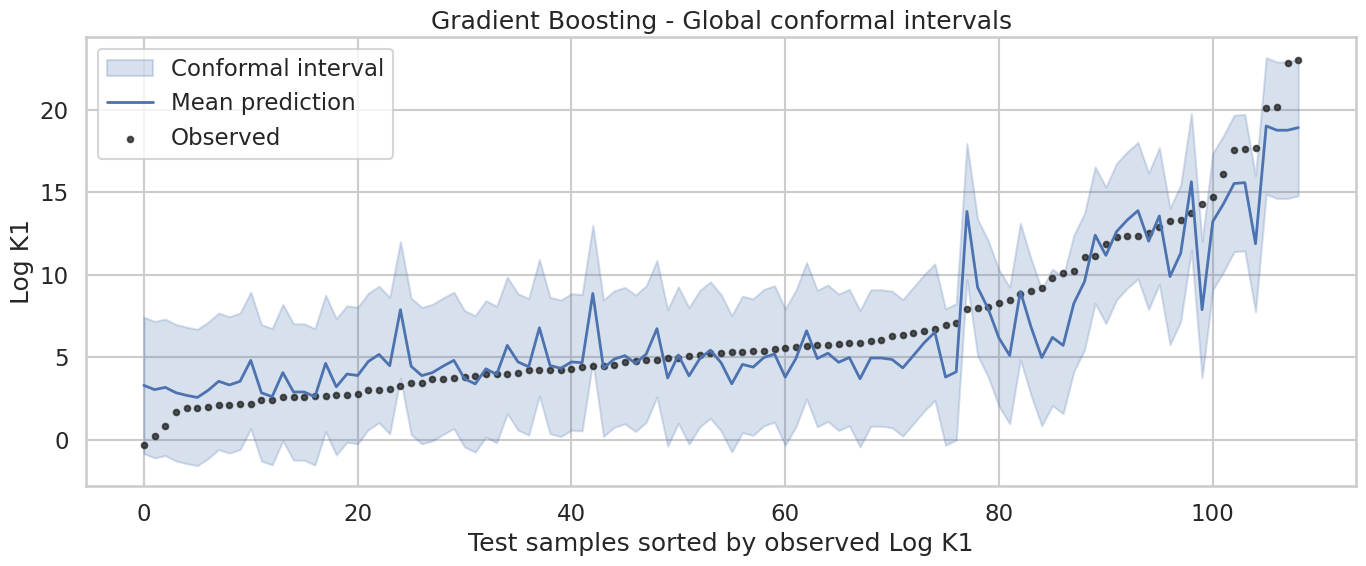

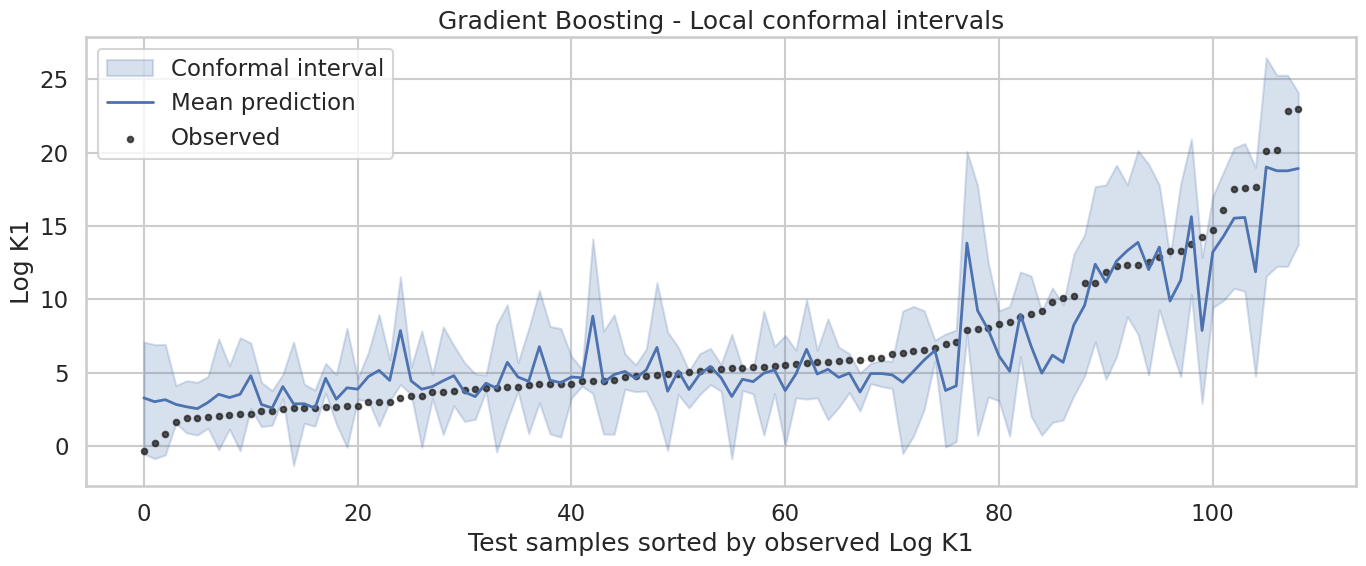

In [3]:
def plot_prediction_intervals(result_frame: pd.DataFrame, model_name: str, method_name: str) -> None:
    subset = result_frame.loc[(result_frame["model"] == model_name) & (result_frame["method"] == method_name)].copy()
    subset = subset.sort_values("observed").reset_index(drop=True)
    x = np.arange(len(subset))

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.fill_between(x, subset["lower"], subset["upper"], color="#4C72B0", alpha=0.22, label="Conformal interval")
    ax.plot(x, subset["predicted"], color="#4C72B0", linewidth=2, label="Mean prediction")
    ax.scatter(x, subset["observed"], color="#222222", s=16, alpha=0.75, label="Observed")
    ax.set_title(f"{model_name.replace('_', ' ').title()} - {method_name.title()} conformal intervals")
    ax.set_xlabel("Test samples sorted by observed Log K1")
    ax.set_ylabel("Log K1")
    ax.legend(loc="best")
    fig.tight_layout()
    fig.savefig(CONFORMAL_RESULTS_ROOT / f"{model_name}_{method_name}_intervals.png", dpi=200, bbox_inches="tight")
    plt.show()


for model_name in BASE_MODELS:
    for method_name in ["global", "local"]:
        plot_prediction_intervals(conformal_results_df, model_name, method_name)
